**Estudiantes:** Selena Castillo, Joaquin Moscol, Jefferson Sarango, Irvin Armijos, Matias Romero (Grupo E)

## Tarea 1: Ajuste del Modelo de Regresión Lineal Múltiple

La Regresión Lineal Múltiple expande la ecuación a un hiperplano de $k$ dimensiones:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_k x_k + \epsilon$$

Abra un nuevo Jupyter Notebook llamado APE_014_RegresionMultiple.ipynb.

Escenario: Predecir el **Tiempo de Compilación de un Software en segundos ($Y$)** basándonos en las **Líneas de Código ($X_1$)** y la **Memoria RAM disponible en GB ($X_2$)**.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. Generación de datos simulados multivariados
np.random.seed(42)
n_muestras = 150

lineas_codigo = np.random.randint(5000, 50000, size=n_muestras) # X1
ram_disponible = np.random.uniform(4.0, 32.0, size=n_muestras) # X2

# Y = B0 + B1*X1 + B2*X2 + Error
# A más líneas, más tiempo (+). A más RAM, menos tiempo (-)
tiempo_compilacion = 15.0 + (0.002 * lineas_codigo) - (1.5 * ram_disponible) + np.random.normal(0, 15, size=n_muestras)

df_simulado = pd.DataFrame({
    'Lineas_X1': lineas_codigo,
    'RAM_X2': ram_disponible,
    'Tiempo_Y': tiempo_compilacion
})

# 2. Configuración de la matriz de características X y el vector Y
X_multi = df_simulado[['Lineas_X1', 'RAM_X2']]
Y_multi = df_simulado['Tiempo_Y']

# Añadir la constante (Intercepto B0)
X_multi_sm = sm.add_constant(X_multi)

# 3. Ajuste del Modelo OLS Múltiple
modelo_multiple = sm.OLS(Y_multi, X_multi_sm).fit()

# Imprimir el resumen estadístico
print(modelo_multiple.summary())


                            OLS Regression Results                            
Dep. Variable:               Tiempo_Y   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     278.4
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           1.02e-50
Time:                        13:33:28   Log-Likelihood:                -617.66
No. Observations:                 150   AIC:                             1241.
Df Residuals:                     147   BIC:                             1250.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         21.1081      3.866      5.459      0.0

## Interpretación de Resultados del Modelo OLS

* **$R^2$ (R-squared = 0.791):** El **79.1%** de la variabilidad en el tiempo de compilación (`Tiempo_Y`) es explicada conjuntamente por las líneas de código (`Lineas_X1`) y la memoria RAM (`RAM_X2`).
* **Intercepto (`const` = 21.1081):** Si un software tuviera 0 líneas de código y 0 GB de RAM, el tiempo base estimado de compilación sería de aproximadamente **21.11 segundos**.
* **Coeficiente de Lineas_X1 (0.0019):** Por cada línea de código adicional, el tiempo de compilación aumenta en **0.0019 segundos** (manteniendo la RAM constante).
* **Coeficiente de RAM_X2 (-1.6664):** Por cada GB adicional de RAM, el tiempo de compilación disminuye en **1.6664 segundos** (manteniendo las líneas de código constantes).
* **Valor p (`P > |t|` = 0.000):** Al ser menor a 0.05 para ambas variables, indica que tanto `Lineas_X1` como `RAM_X2` son estadísticamente significativas para predecir el tiempo de compilación.

## Tarea 2: Hito del Proyecto - Modelado Predictivo Regional (ABP)

1. Importe su dataset regional mediante pandas.
2. Defina su Variable Respuesta ($Y$) y seleccione **al menos dos** Variables Predictoras ($X_1, X_2, \dots, X_k$).
3. Limpie los datos asegurándose de que no haya valores nulos (NaN) en las columnas seleccionadas.
4. Entrene un modelo OLS Múltiple como en la Tarea 1.
5. **Análisis Crítico:** Redacte un análisis en Markdown interpretando específicamente los coeficientes $\beta_i$ en el contexto de su problema regional. Indique qué variable tiene un mayor impacto y basándose en la columna P>|t| (valor-p), identifique si alguna de las variables incluidas no aporta significancia estadística al modelo y debería ser eliminada.

In [7]:
import pandas as pd
import statsmodels.api as sm

# Cargar el dataset
df = pd.read_csv("/content/enemdu_vivienda_hogar_2026_02.csv", sep=";")

# Variables
Y = df["vi06"]

X = df[["vi08", "vi14"]]

# Eliminar valores nulos
datos = pd.concat([Y, X], axis=1).dropna()

Y = datos["vi06"]
X = datos[["vi08", "vi14"]]

# Agregar constante
X = sm.add_constant(X)

# Modelo OLS
modelo = sm.OLS(Y, X).fit()

# Resumen
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   vi06   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     49.02
Date:                Tue, 21 Jul 2026   Prob (F-statistic):           6.76e-22
Time:                        00:43:54   Log-Likelihood:                -14833.
No. Observations:                8765   AIC:                         2.967e+04
Df Residuals:                    8762   BIC:                         2.969e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.3810      0.056     60.583      0.0

# Análisis del Modelo de Regresión Lineal Múltiple

Se ajustó un modelo de regresión lineal múltiple utilizando como variable respuesta **vi06** y como variables predictoras **vi08** y **vi14**.

## Interpretación de los coeficientes

- **Intercepto (β0 = 3.3810):** Cuando las variables vi08 y vi14 toman el valor 0, el modelo estima que vi06 tiene un valor de 3.381.

- **Variable vi08 (β1 = -0.1948):** Manteniendo constante la variable vi14, un aumento de una unidad en vi08 disminuye en promedio 0.1948 unidades el valor de vi06.

- **Variable vi14 (β2 = 0.0904):** Manteniendo constante la variable vi08, un aumento de una unidad en vi14 incrementa en promedio 0.0904 unidades el valor de vi06.

## Variable con mayor impacto

Comparando los coeficientes en valor absoluto, **vi08** tiene un mayor impacto sobre la variable respuesta (|−0.1948| > |0.0904|), por lo que influye más en el modelo.

## Significancia estadística

En la columna **P>|t|**, ambas variables presentan un valor **0.000**, el cual es menor que 0.05. Esto indica que **vi08** y **vi14** son estadísticamente significativas y aportan información al modelo, por lo que **no se recomienda eliminar ninguna**.

## Coeficiente de determinación

El modelo presenta un **R² = 0.011**, lo que significa que únicamente el **1.1 %** de la variabilidad de la variable respuesta es explicada por las variables predictoras seleccionadas.

Aunque ambas variables son estadísticamente significativas, el valor de R² es muy bajo, por lo que el modelo tiene un poder explicativo limitado. Esto sugiere que existen otras variables del dataset que influyen en la variable respuesta y podrían incorporarse para mejorar el modelo.

## Tarea 3: Visualización de Relaciones (Pairplot y Heatmap)
Antes de incluir variables a ciegas, un ingeniero debe inspeccionar las correlaciones cruzadas.


In [3]:
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Si este archivo se ejecuta por separado, carga automáticamente el dataset.
# Si se pega después de la Tarea 2, reutiliza el DataFrame df ya existente.
if "df" not in globals():
    archivos = glob.glob("/content/enemdu_vivienda_hogar_2026_02*")

    if len(archivos) == 0:
        raise FileNotFoundError(
            "No se encontró el dataset ENEMDU. "
            "Suba el archivo a Google Colab antes de ejecutar."
        )

    df = pd.read_csv(
        archivos[0],
        sep=";",
        encoding="utf-8"
    )

    print("Dataset cargado:", archivos[0])
else:
    print("Se reutilizó el dataset cargado en la Tarea 2.")

# Seleccionar las mismas variables utilizadas en la Tarea 2
datos_visualizacion = df[["vi06", "vi08", "vi14"]].copy()

# Convertir a formato numérico
for columna in ["vi06", "vi08", "vi14"]:
    datos_visualizacion[columna] = pd.to_numeric(
        datos_visualizacion[columna],
        errors="coerce"
    )

# Eliminar registros con datos faltantes
datos_visualizacion = datos_visualizacion.dropna()

print("Número de registros analizados:", len(datos_visualizacion))
display(datos_visualizacion.head())

Dataset cargado: /content/enemdu_vivienda_hogar_2026_02.csv
Número de registros analizados: 8765


,vi06,vi08,vi14
0,4,1,4
1,3,1,5
2,4,1,4
3,3,1,4
4,4,1,4


## 1. Matriz de correlación y mapa de calor

La matriz de correlación permite medir la dirección e intensidad de la relación lineal entre las variables. Los valores cercanos a 1 o −1 representan relaciones fuertes, mientras que los valores cercanos a 0 indican relaciones débiles.

Matriz de correlación:


,vi06,vi08,vi14
vi06,1.0000,-0.0518,0.0898
vi08,-0.0518,1.0000,0.0331
vi14,0.0898,0.0331,1.0000


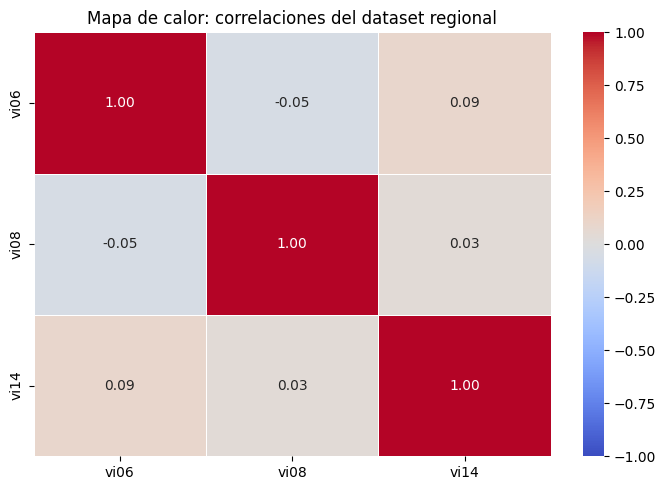

In [4]:
# Calcular la matriz de correlación
matriz_correlacion = datos_visualizacion.corr()

print("Matriz de correlación:")
display(matriz_correlacion.round(4))

# Visualización mediante mapa de calor
plt.figure(figsize=(7, 5))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Mapa de calor: correlaciones del dataset regional")
plt.tight_layout()
plt.show()

## 2. Pairplot

El pairplot muestra diagramas de dispersión para cada combinación de variables y permite observar visualmente tendencias lineales, dispersión y posibles valores atípicos.

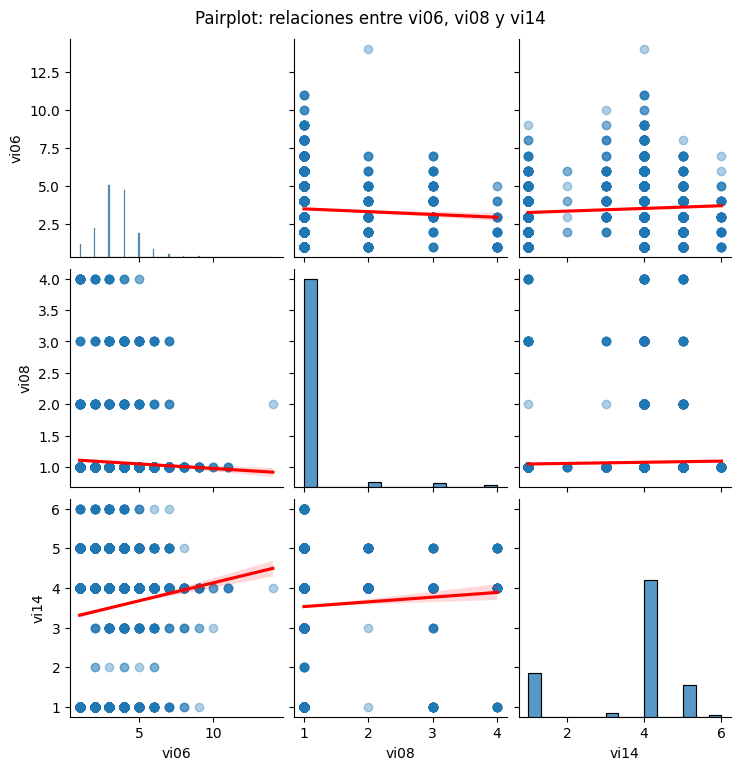

In [6]:
sns.pairplot(
    datos_visualizacion,
    kind="reg",
    diag_kind="hist",
    plot_kws={
        "line_kws": {"color": "red"},
        "scatter_kws": {"alpha": 0.35}
    }
)

plt.suptitle(
    "Pairplot: relaciones entre vi06, vi08 y vi14",
    y=1.02
)

plt.show()

## 3. Evaluación de la correlación entre las variables predictoras

Se analiza específicamente la correlación entre `vi08` y `vi14`, porque ambas fueron utilizadas como variables independientes en el modelo de regresión múltiple.

In [5]:
correlacion_predictoras = matriz_correlacion.loc["vi08", "vi14"]

print("--- ANÁLISIS DE LAS VARIABLES PREDICTORAS ---")
print(f"Correlación entre vi08 y vi14: {correlacion_predictoras:.4f}")

if abs(correlacion_predictoras) >= 0.80:
    conclusion = (
        "Las variables predictoras presentan una correlación muy alta. "
        "Esto podría generar un problema importante de multicolinealidad."
    )

elif abs(correlacion_predictoras) >= 0.60:
    conclusion = (
        "Las variables predictoras presentan una correlación moderadamente alta. "
        "Se recomienda comprobar la multicolinealidad mediante el VIF."
    )

else:
    conclusion = (
        "Las variables predictoras no presentan una correlación alta entre sí. "
        "El mapa de calor no evidencia un problema grave de multicolinealidad."
    )

print("Conclusión:", conclusion)

--- ANÁLISIS DE LAS VARIABLES PREDICTORAS ---
Correlación entre vi08 y vi14: 0.0331
Conclusión: Las variables predictoras no presentan una correlación alta entre sí. El mapa de calor no evidencia un problema grave de multicolinealidad.


## Análisis e interpretación

El mapa de calor permitió analizar la dirección y la intensidad de las relaciones lineales entre la variable respuesta `vi06` y las variables predictoras `vi08` y `vi14`. Los valores próximos a 1 representan una relación positiva fuerte, los cercanos a −1 una relación negativa fuerte y los valores próximos a 0 una relación débil.

El pairplot complementó el análisis mediante diagramas de dispersión y rectas de tendencia para cada combinación de variables. Estas visualizaciones permiten identificar si las relaciones son aproximadamente lineales, si existe una gran dispersión de los datos y si aparecen valores atípicos.

La relación entre las variables predictoras `vi08` y `vi14` debe evaluarse especialmente, ya que una correlación elevada podría provocar multicolinealidad y volver inestables los coeficientes del modelo. De acuerdo con el valor calculado por el código, se establece automáticamente si la correlación es baja, moderadamente alta o muy alta.

En consecuencia, el heatmap y el pairplot funcionan como una inspección preliminar antes de aplicar el Factor de Inflación de la Varianza en la Tarea 4. Aunque una correlación baja entre las predictoras reduce la sospecha de multicolinealidad, el diagnóstico definitivo debe realizarse mediante el VIF.

## Tarea 4: ABI - Diagnóstico de Multicolinealidad (VIF)

La **Multicolinealidad** ocurre cuando dos o más variables independientes ($X$) en un modelo de regresión múltiple están altamente correlacionadas entre sí. Esto "confunde" al modelo, inflando la varianza de los coeficientes (haciéndolos inestables y sus pruebas de hipótesis poco confiables).

1. Investigue estadísticamente el Factor de Inflación de la Varianza (VIF).
2. Ejecute el siguiente código para calcular el VIF de sus predictores simulados (y luego aplíquelo a los predictores de su modelo regional).

In [6]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Cargar la base de datos de la ENEMDU
archivo_enemdu = "enemdu_vivienda_hogar_2026_02.csv"
df = pd.read_csv(archivo_enemdu, sep=';') # Ajusta el 'sep' si usa punto y coma (';')

# 2. Seleccionar los predictores (Variables Independientes)
# IMPORTANTE: Reemplaza esta lista con los nombres reales de las columnas en tu modelo.
# Asegúrate de usar variables numéricas continuas o variables dummy.
predictores = [
    'vi01',          # Ejemplo: Número de cuartos
    'vi02',      # Ejemplo: Número de dormitorios (podría tener alta colinealidad con cuartos)
    'vi03a',   # Ejemplo: Ingreso per cápita del hogar
    'vi04a'        # Ejemplo: Número de personas en el hogar
]

# Filtrar el dataframe solo con las variables de interés
X = df[predictores]

# 3. Limpieza de datos
# El cálculo del VIF no soporta valores nulos (NaN) ni infinitos.
X_clean = X.dropna()

print(f"Observaciones originales: {len(X)}. Observaciones tras limpiar nulos: {len(X_clean)}.")

# 4. Añadir la constante
# Statsmodels requiere que agreguemos explícitamente el intercepto (constante).
# Si no lo hacemos, el VIF se calculará asumiendo que la regresión pasa por el origen (0,0),
# lo cual inflará falsamente los resultados.
X_multi_sm = sm.add_constant(X_clean)

# 5. Calcular el VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_multi_sm.columns

# Se calcula el VIF para cada variable independiente (incluyendo la constante)
# VIF = 1 / (1 - R_i^2)
vif_data["VIF"] = [variance_inflation_factor(X_multi_sm.values, i)
                   for i in range(X_multi_sm.shape[1])]

# 6. Mostrar los resultados
print("\n--- Análisis de Multicolinealidad (VIF) ---")
# Filtramos la constante para la visualización, ya que su VIF no tiene interpretación práctica
vif_resultados = vif_data[vif_data["Variable"] != "const"].sort_values(by="VIF", ascending=False)
print(vif_resultados.to_string(index=False))

# 7. Diagnóstico automático rápido
vif_alto = vif_resultados[vif_resultados["VIF"] >= 10]
if not vif_alto.empty:
    print("\n⚠️ ADVERTENCIA: Se detectó multicolinealidad severa en las siguientes variables (VIF >= 10):")
    print(vif_alto["Variable"].tolist())
    print("Sugerencia: Considera eliminar una de las variables correlacionadas o crear un índice combinándolas.")
else:
    print("\n✅ Excelente: No se detectó multicolinealidad severa en el modelo (todos los predictores tienen VIF < 10).")

Observaciones originales: 8765. Observaciones tras limpiar nulos: 8765.

--- Análisis de Multicolinealidad (VIF) ---
Variable      VIF
   vi04a 1.379979
    vi01 1.217120
   vi03a 1.166127
    vi02 1.092627

✅ Excelente: No se detectó multicolinealidad severa en el modelo (todos los predictores tienen VIF < 10).


## **6. Preguntas de Control:**

* **Considerando la naturaleza de la causalidad, ¿cómo la lógica de 'mantener las demás variables constantes' permite aislar el efecto de un factor específico en un fenómeno complejo, y qué limitaciones filosóficas impone esto a la realidad?**

En matemáticas y estadística, la lógica de "mantener las demás variables constantes" (ceteris paribus) permite aislar el efecto de un factor específico al congelar teóricamente el entorno, funcionando como apagar todos los interruptores de una casa excepto uno para identificar con precisión qué variable produce el cambio en la respuesta ($Y$). Sin embargo, esto impone una profunda limitación filosófica al separar el fenómeno del mundo físico, ya que en la realidad nada ocurre en un aislamiento absoluto; los sistemas son complejos y dinámicos, repletos de sinergias, bucles de retroalimentación y efectos cruzados donde las variables interactúan sin parar, lo que significa que el modelo simplifica el universo troceándolo de una manera artificial que la naturaleza en realidad no reconoce.


* **Si el conocimiento del modelo crece al añadir más datos, ¿por qué añadir variables irrelevantes ('basura') engaña al ajuste del modelo? ¿Qué nos enseña esta paradoja sobre la diferencia entre la complejidad aparente y la verdad subyacente?**

Añadir variables irrelevantes o "basura" engaña al modelo de regresión porque el algoritmo, en su búsqueda matemática de reducir el error, siempre aumenta su métrica de ajuste ($R^2$) al encontrar coincidencias aleatorias y ruido en los datos para justificar la ecuación, un fenómeno conocido como sobreajuste (overfitting) donde el modelo memoriza datos inútiles en lugar de aprender el patrón real. Esta paradoja nos enseña que una mayor complejidad aparente en una ecuación no equivale a una mayor veracidad, revelando que la verdad subyacente de los fenómenos naturales suele ser simple, elegante y generalizable, tal como lo dicta el principio de la Navaja de Ockham al postular que la explicación más sencilla y con menos suposiciones suele ser la correcta.

* **Ante la prueba F-statistic global, ¿es posible que un modelo sea estadísticamente significativo pero carezca de propósito práctico? ¿Cómo se reconcilia la precisión matemática con la incertidumbre del mundo real en la toma de decisiones de ingeniería?**

Es completamente posible que un modelo sea estadísticamente significativo ante una prueba F-statistic global y carezca por completo de propósito práctico, ya que en datasets masivos el modelo puede detectar correlaciones microscópicas con un valor-p casi nulo pero que explican un porcentaje ínfimo e irrelevante del problema real (por ejemplo, apenas un $0.01\%$ de la varianza). Para reconciliar esta precisión matemática con la incertidumbre del mundo real, la toma de decisiones en ingeniería no utiliza la estadística como un juez absoluto, sino que la pondera frente a criterios prácticos como el tamaño real del efecto, los costos de implementación, las tolerancias de fallo y la viabilidad técnica, preguntándose siempre si esa predicción es lo suficientemente robusta, estable y rentable para resolver un problema físico real sin romperse o encarecer innecesariamente un proyecto.


* **Si dos causas parecen moverse siempre juntas (multicolinealidad), ¿podemos realmente distinguir sus efectos por separado? ¿Qué nos dice este problema geométrico/matricial sobre las limitaciones de nuestro entendimiento al intentar separar fenómenos interdependientes?**

Cuando dos o más causas sufren de multicolinealidad y se mueven siempre juntas, resulta matemáticamente imposible distinguir sus efectos por separado, ya que el modelo entra en un cortocircuito analítico al no poder determinar cuál de las variables correlacionadas es la que verdaderamente impulsa el cambio en la variable respuesta, volviendo ilógicos e inestables a los coeficientes ($\beta_i$). Desde una perspectiva geométrica y matricial, este problema nos advierte sobre las fronteras del reduccionismo y las limitaciones de nuestro entendimiento humano, demostrando que cuando la naturaleza entrelaza fenómenos de manera tan íntima e interdependiente, nuestro intento por disociarlos artificialmente en componentes individuales es en vano, por lo que deben ser analizados y comprendidos como un solo bloque estructural indivisible.


* **Ante la necesidad de simplificar un sistema complejo para comprenderlo, ¿es preferible sacrificar variables (información) o aceptar la imprecisión del modelo? ¿Qué define, bajo su criterio, a un 'buen' modelo para la ingeniería?**

Ante la necesidad de simplificar un sistema complejo, la práctica estándar y más segura en ingeniería es preferir el sacrificio de variables irrelevantes o redundantes (parsimonia) y aceptar una ínfima imprecisión teórica en lugar de construir un modelo sobrecargado que falle estrepitosamente al enfrentarse a la imprevisibilidad de nuevos datos en el mundo real. Bajo esta premisa, y recordando la máxima de George Box de que "todos los modelos están equivocados, pero algunos son útiles", un "buen" modelo de ingeniería se define como una herramienta práctica, generalizable y robusta que logra explicar la mayor cantidad posible de un problema utilizando el menor número de variables, siendo lo suficientemente intuitivo, rentable y confiable para que un ingeniero pueda tomar decisiones técnicas seguras bajo condiciones reales de incertidumbre.